In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/superstore_clean.csv")
df.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,postal_code,region,product_id,category,sub_category,product_name,sales,quantity,discount,profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [3]:
df.shape, df.columns

((9994, 21),
 Index(['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode',
        'customer_id', 'customer_name', 'segment', 'country', 'city', 'state',
        'postal_code', 'region', 'product_id', 'category', 'sub_category',
        'product_name', 'sales', 'quantity', 'discount', 'profit'],
       dtype='str'))

In [4]:
df.isna().sum().sort_values(ascending=False).head(15)

row_id           0
order_id         0
order_date       0
ship_date        0
ship_mode        0
customer_id      0
customer_name    0
segment          0
country          0
city             0
state            0
postal_code      0
region           0
product_id       0
category         0
dtype: int64

In [5]:
for col in ["order_date", "ship_date"]:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")

df[["order_date","ship_date"]].head() if "order_date" in df.columns else "No date columns found"

,order_date,ship_date
0,2016-11-08,2016-11-11
1,2016-11-08,2016-11-11
2,2016-06-12,2016-06-16
3,2015-10-11,2015-10-18
4,2015-10-11,2015-10-18


In [6]:
total_sales = df["sales"].sum() if "sales" in df.columns else None
total_profit = df["profit"].sum() if "profit" in df.columns else None

total_orders = df["order_id"].nunique() if "order_id" in df.columns else None
total_customers = df["customer_id"].nunique() if "customer_id" in df.columns else None

(total_sales, total_profit, total_orders, total_customers)

(np.float64(2297200.8603), np.float64(286397.0217), 5009, 793)

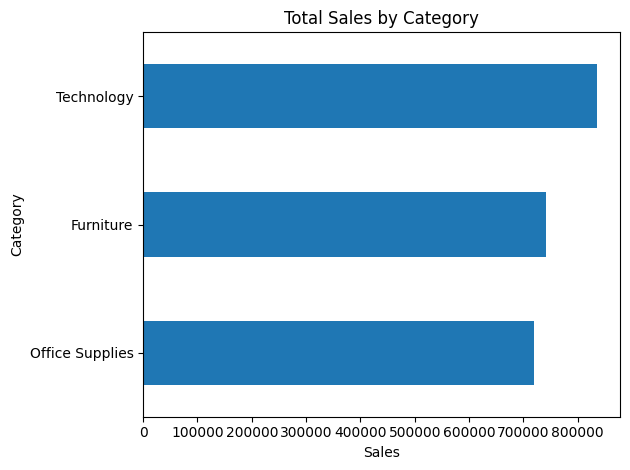

In [7]:
cat_sales = df.groupby("category")["sales"].sum().sort_values()

cat_sales.plot(kind="barh")
plt.title("Total Sales by Category")
plt.xlabel("Sales")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

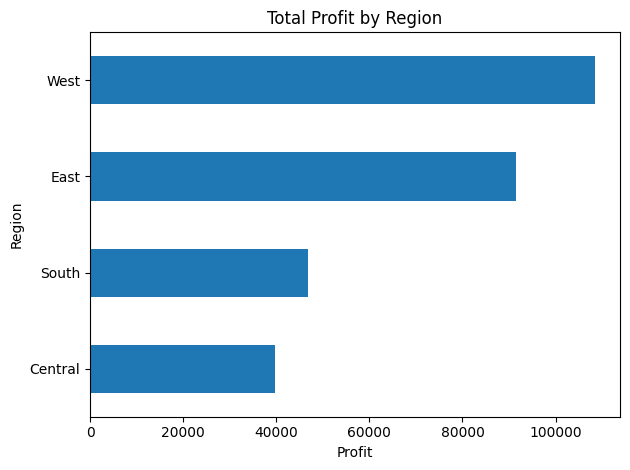

In [8]:
region_profit = df.groupby("region")["profit"].sum().sort_values()

region_profit.plot(kind="barh")
plt.title("Total Profit by Region")
plt.xlabel("Profit")
plt.ylabel("Region")
plt.tight_layout()
plt.show()

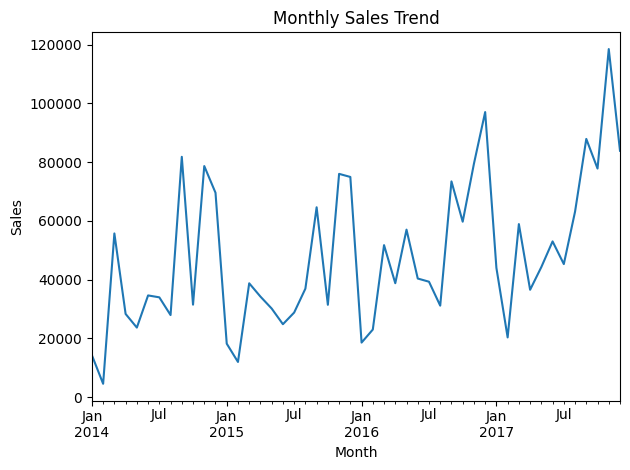

In [10]:
if "order_date" in df.columns:
    monthly_sales = df.set_index("order_date").resample("ME")["sales"].sum()

    monthly_sales.plot()
    plt.title("Monthly Sales Trend")
    plt.xlabel("Month")
    plt.ylabel("Sales")
    plt.tight_layout()
    plt.show()
else:
    print("order_date not found")

In [11]:
top_products = df.groupby("product_name")["sales"].sum().sort_values(ascending=False).head(10)
top_products

product_name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: sales, dtype: float64

In [12]:
top_customers = df.groupby("customer_name")["sales"].sum().sort_values(ascending=False).head(10)
top_customers

customer_name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Name: sales, dtype: float64